# CSCI 5527 Deep Learning Project
## Team: Beep Learning

### Get the Data from FER2013

In [1]:
%pip install kaggle
%pip install kagglehub
%pip install torch
%pip install torchvision
%pip install optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

import kagglehub
import optuna
from optuna.trial import TrialState

# Add project path in a notebook-friendly, cross-platform way
project_root = next(
    (parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'fer_dataset.py').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Could not find fer_dataset.py. Run the notebook from the repo root or the vanillaCNN folder.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from device_utils import (
    autocast_context,
    build_runtime_config,
    clear_runtime_cache,
    make_dataloader,
    make_grad_scaler,
)
from fer_dataset import FERDataset

runtime = build_runtime_config(max_workers=4)
device = runtime.device
device_type = runtime.device_type
amp_enabled = runtime.amp_enabled
non_blocking = runtime.non_blocking
mps_available = getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available()

print("✓ All libraries imported successfully!")
print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", mps_available)
print("Device name:", runtime.device_name)
print(f"\n✓ Device set to: {device} ({device_type})")
print(f"✓ Mixed precision enabled: {amp_enabled}")

✓ All libraries imported successfully!
Python: /usr/local/bin/python3
Torch version: 2.11.0
Torch CUDA version: None
CUDA available: False
MPS available: True
Device name: Apple Silicon GPU (MPS)

✓ Device set to: mps (mps)
✓ Mixed precision enabled: False


## Import Required Libraries

In [3]:
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)

Path to dataset files: /Users/chenyixin/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [4]:
#!git clone https://github.com/RohitPoduval1/csci5527-project.git

In [5]:
# Verify FERDataset import
print("FERDataset imported successfully!")
print(f"Dataset classes available: {len(FERDataset.__doc__)} emotion types")

FERDataset imported successfully!
Dataset classes available: 161 emotion types


### Load the dataset and split it

In [6]:
# Get the path from kagglehub (you already have this in 'path' variable)
fer_path = path

# Create train and test datasets with transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale images
])

train_dataset = FERDataset(fer_path, split='train', transforms=transform)
test_dataset = FERDataset(fer_path, split='test', transforms=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Emotion classes: {train_dataset.classes}")

Train dataset size: 28709
Test dataset size: 7178
Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


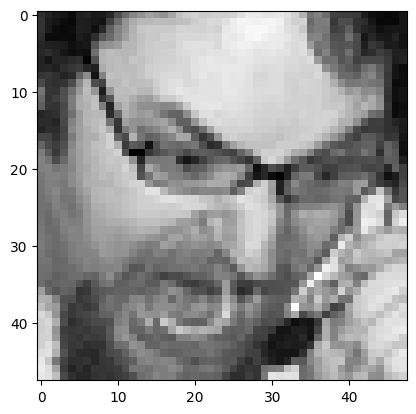

In [7]:
plt.imshow(test_dataset[0][0].squeeze(), cmap='gray')

In [8]:
# Create runtime-aware DataLoaders
train_loader = make_dataloader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    runtime=runtime,
)
test_loader = make_dataloader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    runtime=runtime,
)

print("✓ Runtime-aware DataLoaders created")
print(f"  - device_type: {device_type}")
print(f"  - num_workers: {runtime.num_workers}")
print(f"  - pin_memory: {runtime.pin_memory}")
print(f"  - persistent_workers: {runtime.persistent_workers}")

✓ Runtime-aware DataLoaders created
  - device_type: mps
  - num_workers: 0
  - pin_memory: False
  - persistent_workers: False


In [9]:
class VanillaCNN(nn.Module):
    """Simple CNN for facial emotion recognition"""
    def __init__(self, num_classes=7, dropout_rate=0.25, fc_dropout=0.5):
        super(VanillaCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.dropout4 = nn.Dropout(fc_dropout)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.relu5 = nn.ReLU(inplace=True)
        self.dropout5 = nn.Dropout(fc_dropout)
        
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = self.fc1(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.dropout4(x)
        
        x = self.fc2(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.dropout5(x)
        
        x = self.fc3(x)
        return x

# Initialize model and move to device
model = VanillaCNN(num_classes=len(train_dataset.classes))
model = model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Model parameters: 1,307,591
VanillaCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p

### Train Vanilla CNN (Baseline)

In [10]:
def train_model(model, train_loader, test_loader, num_epochs=50, lr=0.001, patience=10, verbose=True, use_amp=True):
    """
    Train the model and return training history.

    Mixed precision is enabled automatically only when the active runtime supports it.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    amp_active = bool(use_amp and amp_enabled)
    scaler = make_grad_scaler(device_type, amp_active)

    best_val_acc = 0
    patience_counter = 0
    best_model_wts = model.state_dict().copy()

    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accs': [],
        'val_accs': [],
        'best_val_acc': 0,
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=non_blocking)
            labels = labels.to(device, non_blocking=non_blocking)

            optimizer.zero_grad(set_to_none=True)
            with autocast_context(device_type, amp_active):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        history['train_losses'].append(train_loss)
        history['train_accs'].append(train_acc)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device, non_blocking=non_blocking)
                labels = labels.to(device, non_blocking=non_blocking)

                with autocast_context(device_type, amp_active):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                predicted = outputs.argmax(dim=1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(test_loader)
        val_acc = 100 * val_correct / val_total
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)

        scheduler.step(val_loss)

        if verbose and (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {train_acc:.2f}% ({train_loss:.4f}) | Val: {val_acc:.2f}% ({val_loss:.4f})")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)
    history['best_val_acc'] = best_val_acc
    clear_runtime_cache(device_type)
    return history

print("✓ Training function defined with runtime-aware acceleration!")

✓ Training function defined with runtime-aware acceleration!


## Training Execution

### Training Function

## Training

In [11]:
# Train vanilla CNN with default hyperparameters
model_vanilla = VanillaCNN(num_classes=len(train_dataset.classes), dropout_rate=0.25, fc_dropout=0.5)
model_vanilla = model_vanilla.to(device)

print("🚀 Training Vanilla CNN with runtime-aware settings...")
print(f"   Device: {device} ({device_type})")
history_vanilla = train_model(
    model_vanilla, 
    train_loader, 
    test_loader, 
    num_epochs=30, 
    lr=0.001, 
    patience=10,
    use_amp=amp_enabled,
)
torch.save(model_vanilla.state_dict(), 'vanilla_cnn.pth')
print(f"\n✓ Training Complete!")
print(f"  Best Validation Accuracy: {history_vanilla['best_val_acc']:.2f}%")
print(f"  Final Training Accuracy: {history_vanilla['train_accs'][-1]:.2f}%")
print(f"  Final Validation Accuracy: {history_vanilla['val_accs'][-1]:.2f}%")

🚀 Training Vanilla CNN with runtime-aware settings...
   Device: mps (mps)
Epoch [5/30] | Train: 52.62% (1.2487) | Val: 56.26% (1.1350)
Epoch [10/30] | Train: 58.24% (1.1109) | Val: 59.13% (1.0715)
Epoch [15/30] | Train: 62.42% (1.0034) | Val: 62.06% (1.0146)
Epoch [20/30] | Train: 65.86% (0.9255) | Val: 62.44% (1.0208)
Epoch [25/30] | Train: 68.38% (0.8606) | Val: 62.83% (1.0203)
Epoch [30/30] | Train: 71.81% (0.7708) | Val: 63.32% (1.0377)

✓ Training Complete!
  Best Validation Accuracy: 63.37%
  Final Training Accuracy: 71.81%
  Final Validation Accuracy: 63.32%


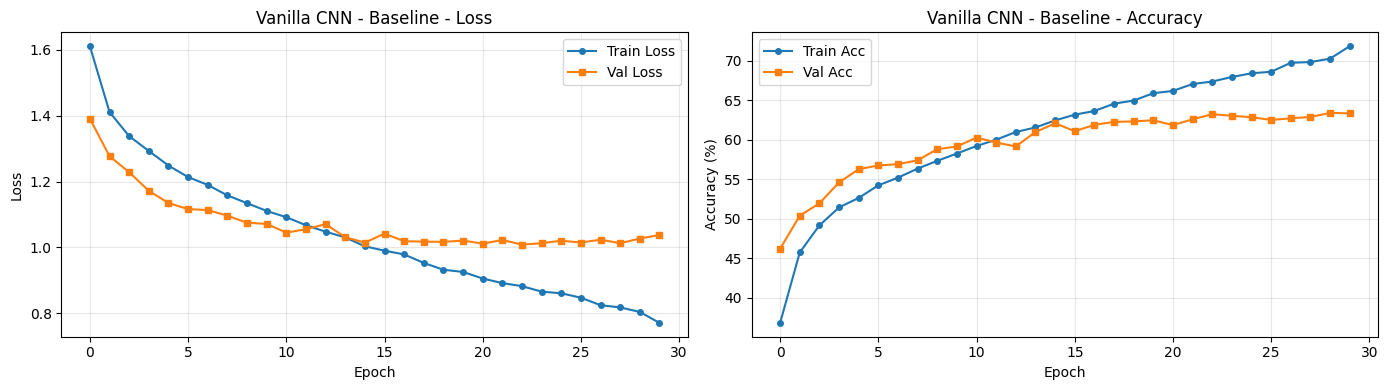

In [12]:
def plot_history(history, title="Training History"):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Loss plot
    ax1.plot(history['train_losses'], label='Train Loss', marker='o', markersize=4)
    ax1.plot(history['val_losses'], label='Val Loss', marker='s', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history['train_accs'], label='Train Acc', marker='o', markersize=4)
    ax2.plot(history['val_accs'], label='Val Acc', marker='s', markersize=4)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot vanilla CNN results
plot_history(history_vanilla, "Vanilla CNN - Baseline")

### Vanilla CNN Model

In [13]:
ckpt = torch.load('checkpoints/vanilla_cnn_best.pt', map_location=device)

print(ckpt.keys()) 

loaded_model = VanillaCNN(
    num_classes=len(train_dataset.classes),
    dropout_rate=0.25,
    fc_dropout=0.5
)

loaded_model.load_state_dict(ckpt["state_dict"])
loaded_model = loaded_model.to(device)
loaded_model.eval()

dict_keys(['state_dict', 'epoch', 'history', 'model_kwargs', 'class_names', 'module_attr', 'pytorch_version', 'extra'])


VanillaCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p=0.25, inplace=False)
  (fc1

In [14]:
from eval_utils import run_inference_sweep
df_results = run_inference_sweep(
    model=loaded_model,                 # or your trained model like model_best
    dataloader=test_loader,        # use the dataset, not the loader
    device=device)
print(df_results.head())

100%|██████████| 225/225 [00:07<00:00, 30.89it/s]

   batch_idx  img_idx_in_batch  true_label  pred_label      prob
0          0                 0           0           3  0.478661
1          0                 1           0           0  0.939626
2          0                 2           0           5  0.817131
3          0                 3           0           0  0.424177
4          0                 4           0           0  0.966732


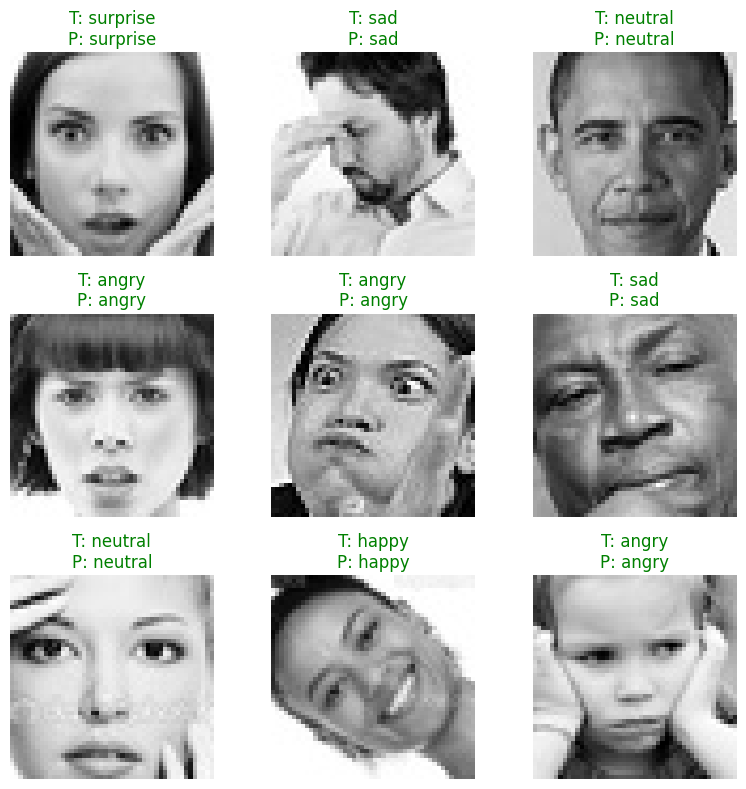

In [15]:
import matplotlib.pyplot as plt
import torch

# Get a batch
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

# Forward pass
with torch.no_grad():
    outputs = loaded_model(images)
    preds = outputs.argmax(dim=1)

# Visualize
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i in range(9):
    ax = axes[i // 3, i % 3]
    
    img = images[i][0].cpu().numpy()
    
    true_label = train_dataset.classes[labels[i].item()]
    pred_label = train_dataset.classes[preds[i].item()]
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"T: {true_label}\nP: {pred_label}",
                 color=("green" if true_label == pred_label else "red"))
    ax.axis('off')

plt.tight_layout()
plt.show()

## Grad-CAM Visualization

Use the trained CNN to visualize which facial regions contribute most to each prediction. This section prefers `model_best` when available and falls back to `model_vanilla`.


Grad-CAM model: Vanilla CNN (.pt checkpoint)
Target layer: Conv2d
Sample indices: [0, 1, 2, 3, 4, 5]
Prediction: happy (0.479)
Prediction: angry (0.940)
Prediction: sad (0.817)
Prediction: angry (0.424)
Prediction: angry (0.967)
Prediction: fear (0.385)


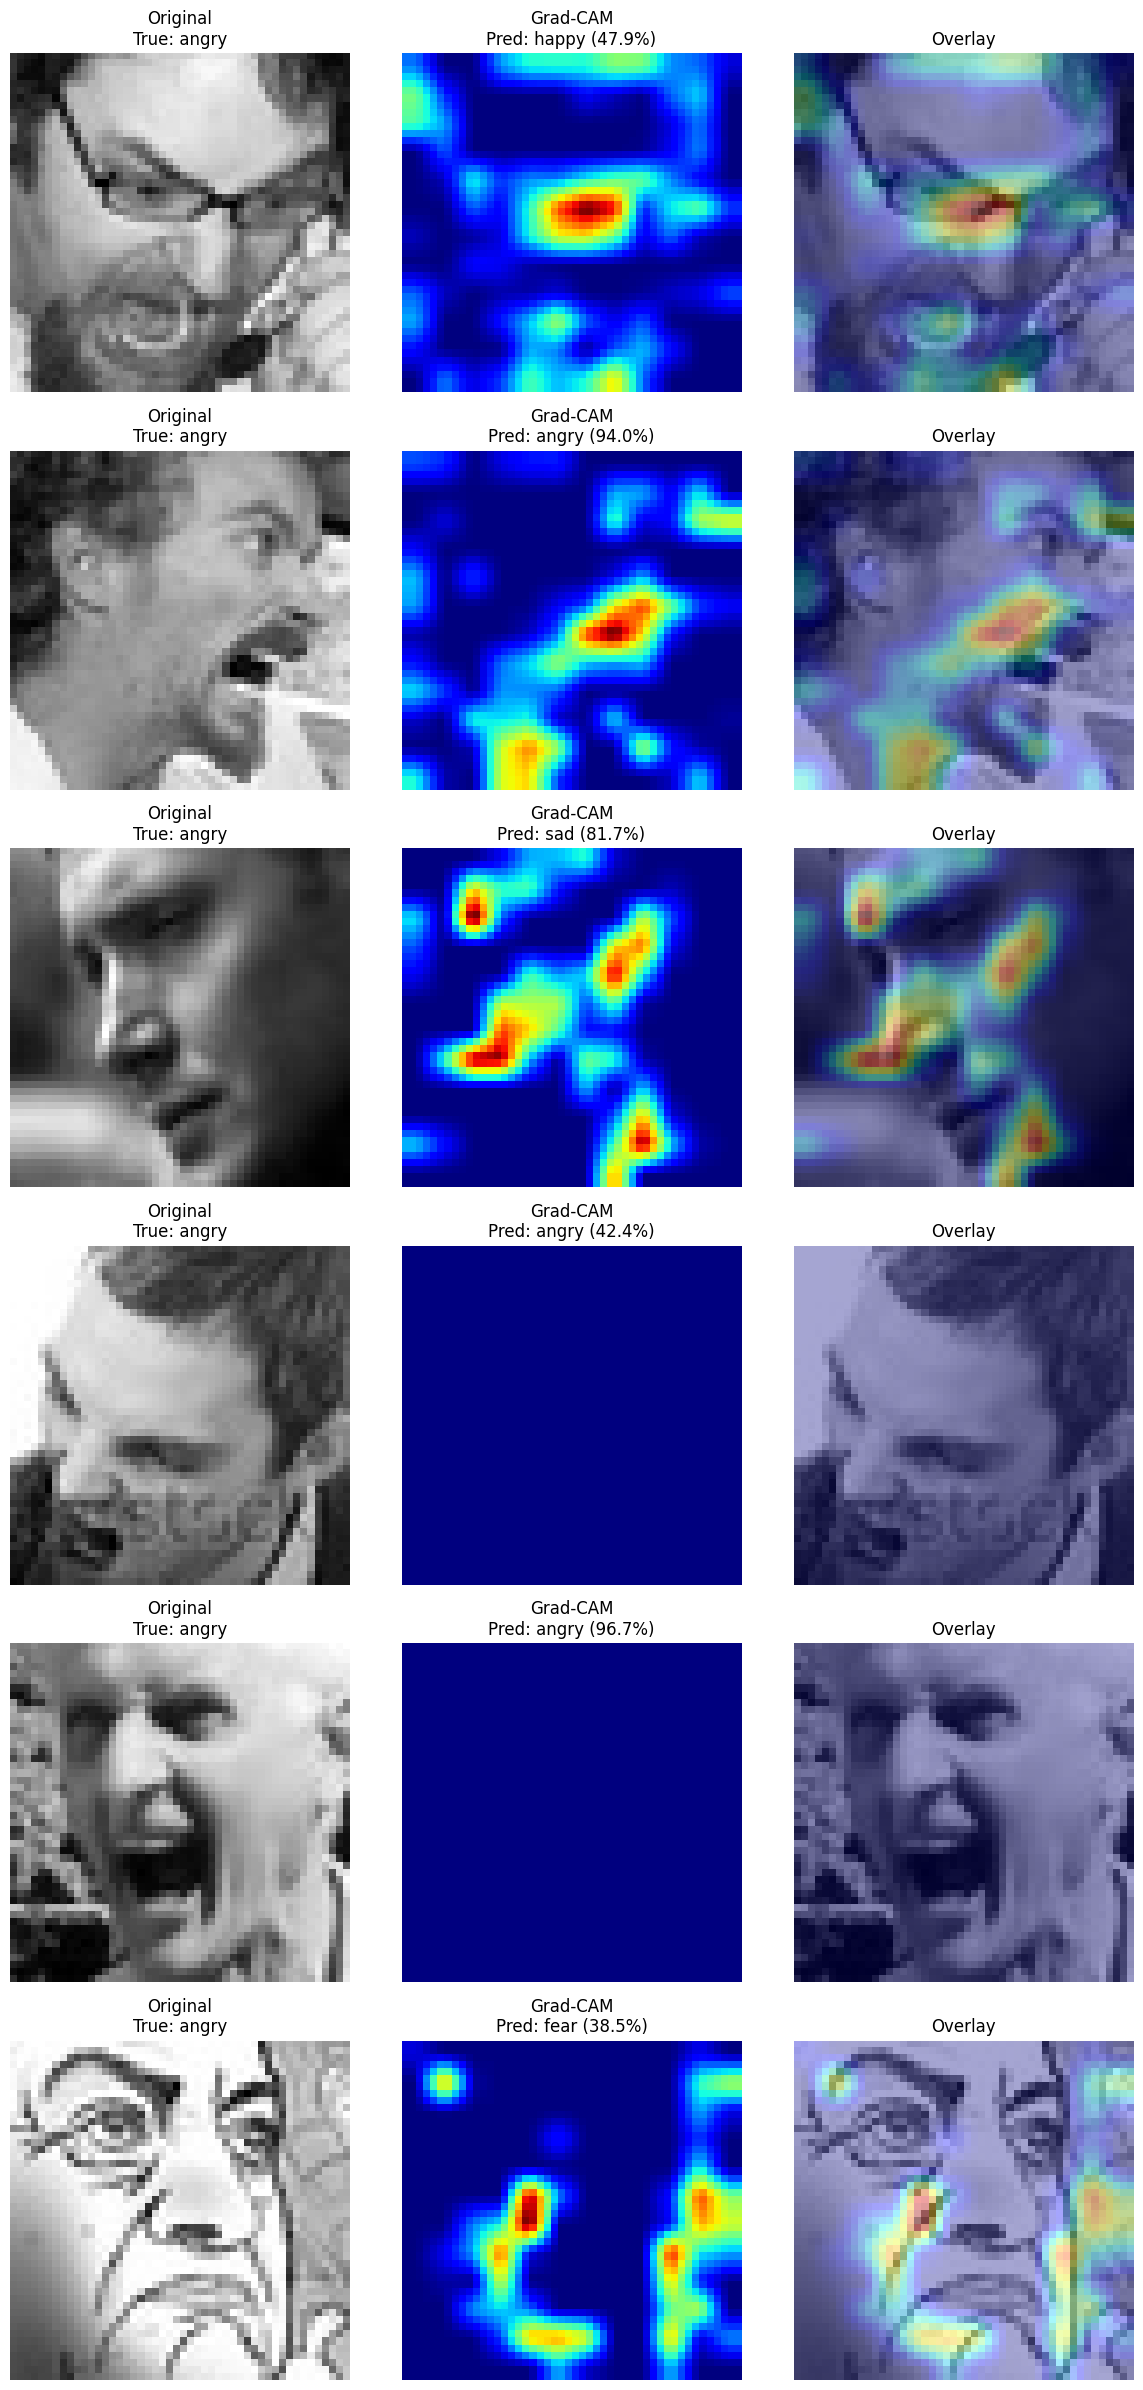

In [16]:
import torch
from gradcam_utils import get_default_target_layer, visualize_gradcam_samples

# Load trained weights
loaded_model.load_state_dict(ckpt["state_dict"])
loaded_model = loaded_model.to(device)
loaded_model.eval()

# Use this loaded model for Grad-CAM
gradcam_model = loaded_model
gradcam_model_name = 'Vanilla CNN (.pt checkpoint)'

# Automatically choose target layer
gradcam_target_layer = get_default_target_layer(gradcam_model)

# Pick first 6 test samples
gradcam_indices = list(range(6))

print(f"Grad-CAM model: {gradcam_model_name}")
print(f"Target layer: {gradcam_target_layer.__class__.__name__}")
print(f"Sample indices: {gradcam_indices}")

_ = visualize_gradcam_samples(
    model=gradcam_model,
    dataset=test_dataset,
    class_names=train_dataset.classes,
    device=device,
    indices=gradcam_indices,
    target_layer=gradcam_target_layer,
)

Comparing custom Grad-CAM vs pytorch-grad-cam on indices: [0, 1, 2]
Prediction: class 3 (0.479)
Prediction: class 0 (0.940)
Prediction: class 5 (0.817)


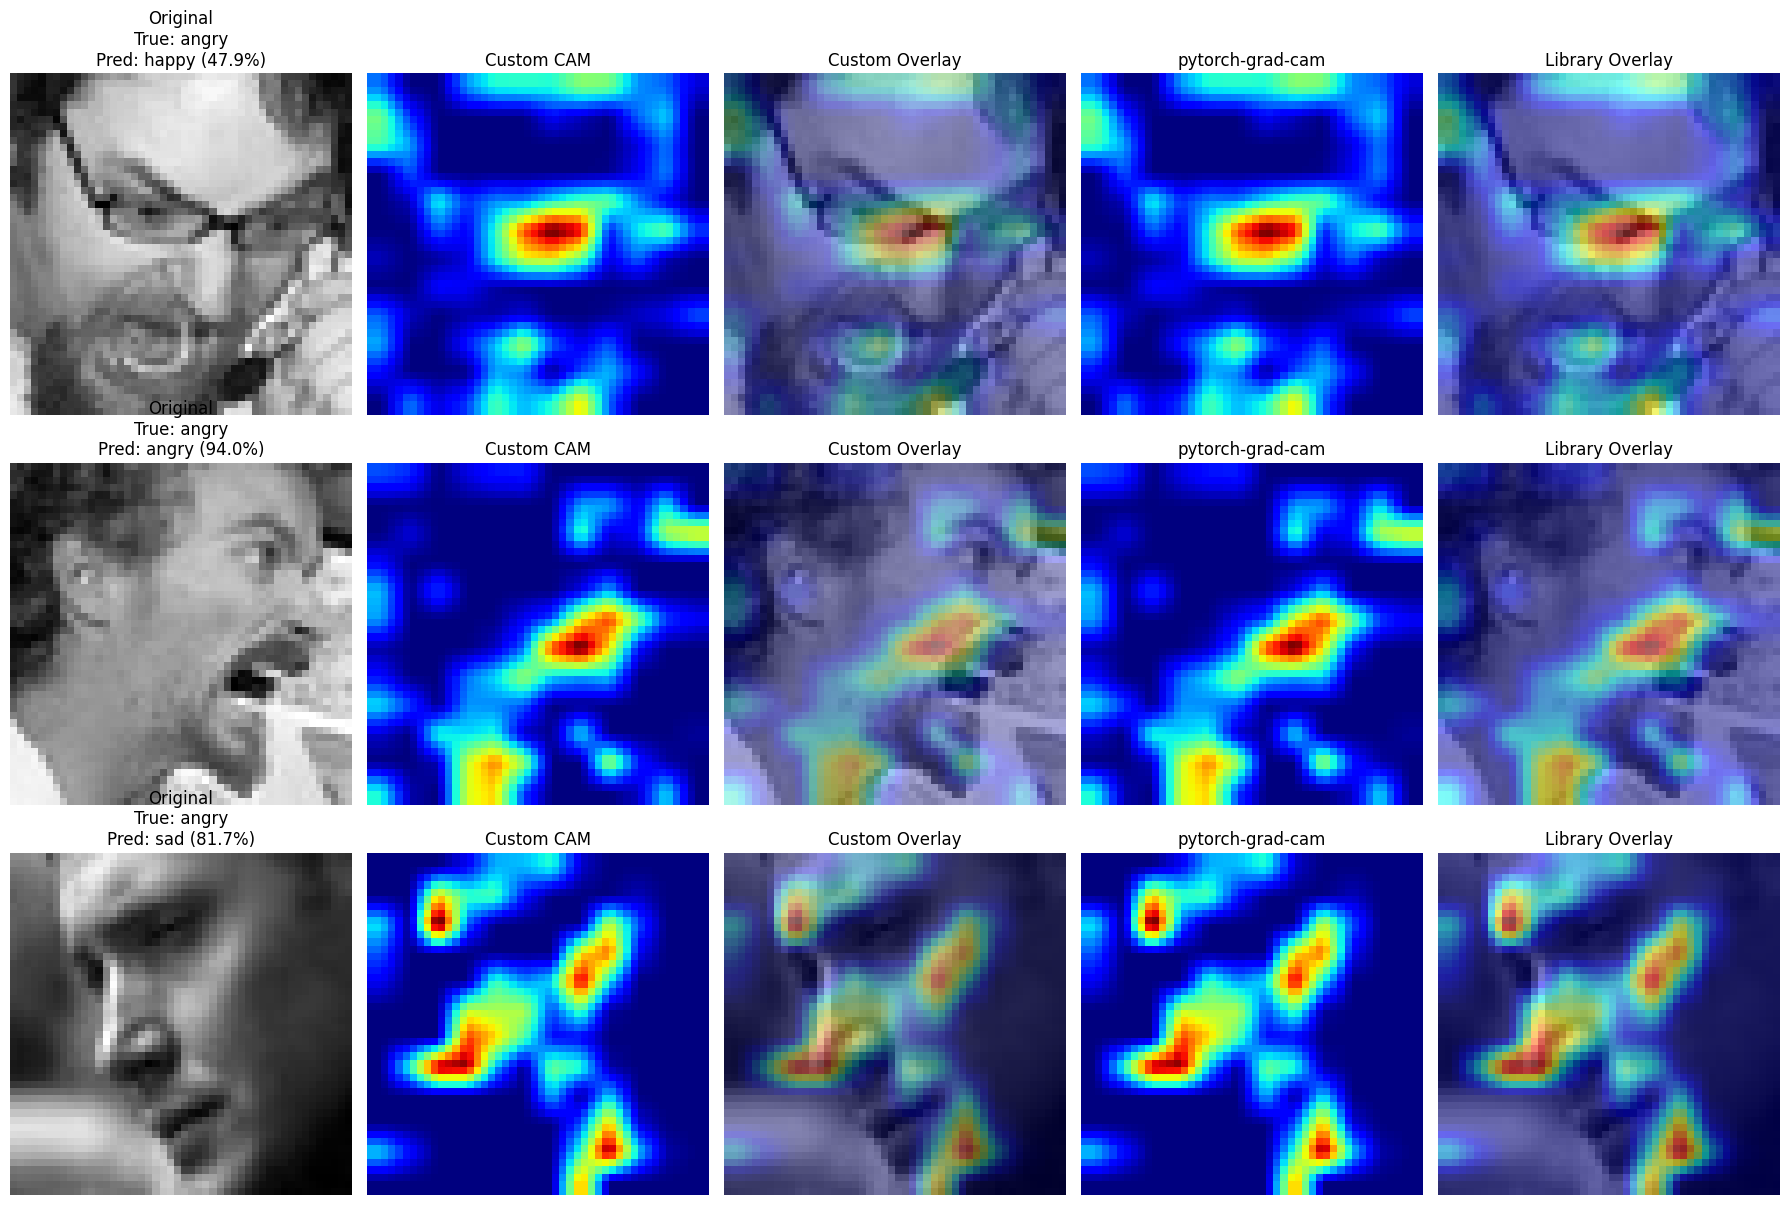

In [17]:
from gradcam_utils import compare_gradcam_methods

comparison_indices = gradcam_indices[:3]
print(f"Comparing custom Grad-CAM vs pytorch-grad-cam on indices: {comparison_indices}")

try:
    _ = compare_gradcam_methods(
        model=gradcam_model,
        dataset=test_dataset,
        class_names=train_dataset.classes,
        device=device,
        indices=comparison_indices,
        target_layer=gradcam_target_layer,
    )
except ImportError as exc:
    print(exc)


In [18]:
def denormalize_image(tensor):
    """Reverses ImageNet normalization to make the image viewable."""
    means = np.array(0.5)
    stds = np.array(0.5)

    img = tensor.cpu().numpy()
    img = stds * img + means
    # img = np.clip(img, 0, 1)
    return img

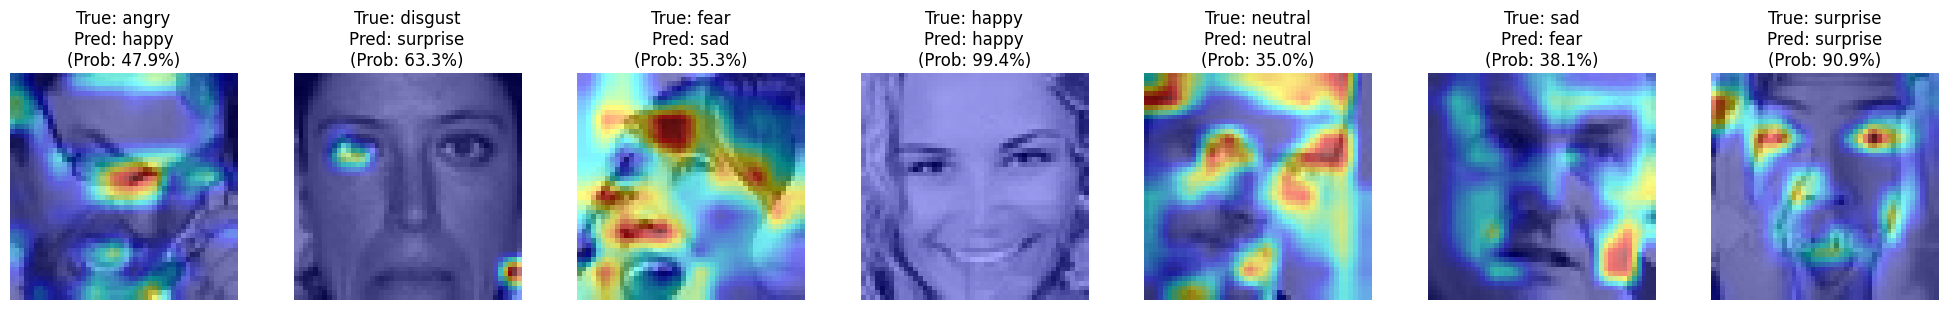

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Find the first example for each class regardless of correctness
first_per_class = df_results.groupby('true_label').head(1).sort_values('true_label')

# Initialize Grad-CAM
target_layers = [loaded_model.conv3]
cam = GradCAM(model=loaded_model, target_layers=target_layers)

dataset = test_loader.dataset
batch_size = test_loader.batch_size

# Create a 1x7 subplot figure
fig, axes = plt.subplots(1, 7, figsize=(20, 3))

for idx, (_, row) in enumerate(first_per_class.iterrows()):
    true_label = int(row['true_label'])
    pred_label = int(row['pred_label'])
    dataset_idx = int(row['batch_idx'] * batch_size + row['img_idx_in_batch'])

    # Grab the original tensor
    image_tensor, _ = dataset[dataset_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Generate heatmap targeting the predicted class
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Convert grayscale tensor to (H, W, 3)
    img = image_tensor.squeeze().cpu().numpy()
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    rgb_img = np.stack([img, img, img], axis=-1)

    # Overlay CAM
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot
    axes[idx].imshow(cam_image)
    true_class_name = dataset.classes[true_label]
    pred_class_name = dataset.classes[pred_label]
    axes[idx].set_title(
        f"True: {true_class_name}\nPred: {pred_class_name}\n(Prob: {row['prob']*100:.1f}%)"
    )
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

(<Figure size 1600x2240 with 35 Axes>,
 array([[<Axes: title={'center': 'True: angry\nPred: sad\nConf: 23.8%'}, ylabel='angry'>,
         <Axes: title={'center': 'True: angry\nPred: fear\nConf: 27.2%'}>,
         <Axes: title={'center': 'True: angry\nPred: sad\nConf: 27.2%'}>,
         <Axes: title={'center': 'True: angry\nPred: neutral\nConf: 27.7%'}>,
         <Axes: title={'center': 'True: angry\nPred: happy\nConf: 27.7%'}>],
        [<Axes: title={'center': 'True: disgust\nPred: neutral\nConf: 28.0%'}, ylabel='disgust'>,
         <Axes: title={'center': 'True: disgust\nPred: fear\nConf: 29.6%'}>,
         <Axes: title={'center': 'True: disgust\nPred: angry\nConf: 30.0%'}>,
         <Axes: title={'center': 'True: disgust\nPred: sad\nConf: 32.3%'}>,
         <Axes: title={'center': 'True: disgust\nPred: sad\nConf: 32.8%'}>],
        [<Axes: title={'center': 'True: fear\nPred: sad\nConf: 24.3%'}, ylabel='fear'>,
         <Axes: title={'center': 'True: fear\nPred: angry\nConf: 24.4%'}>

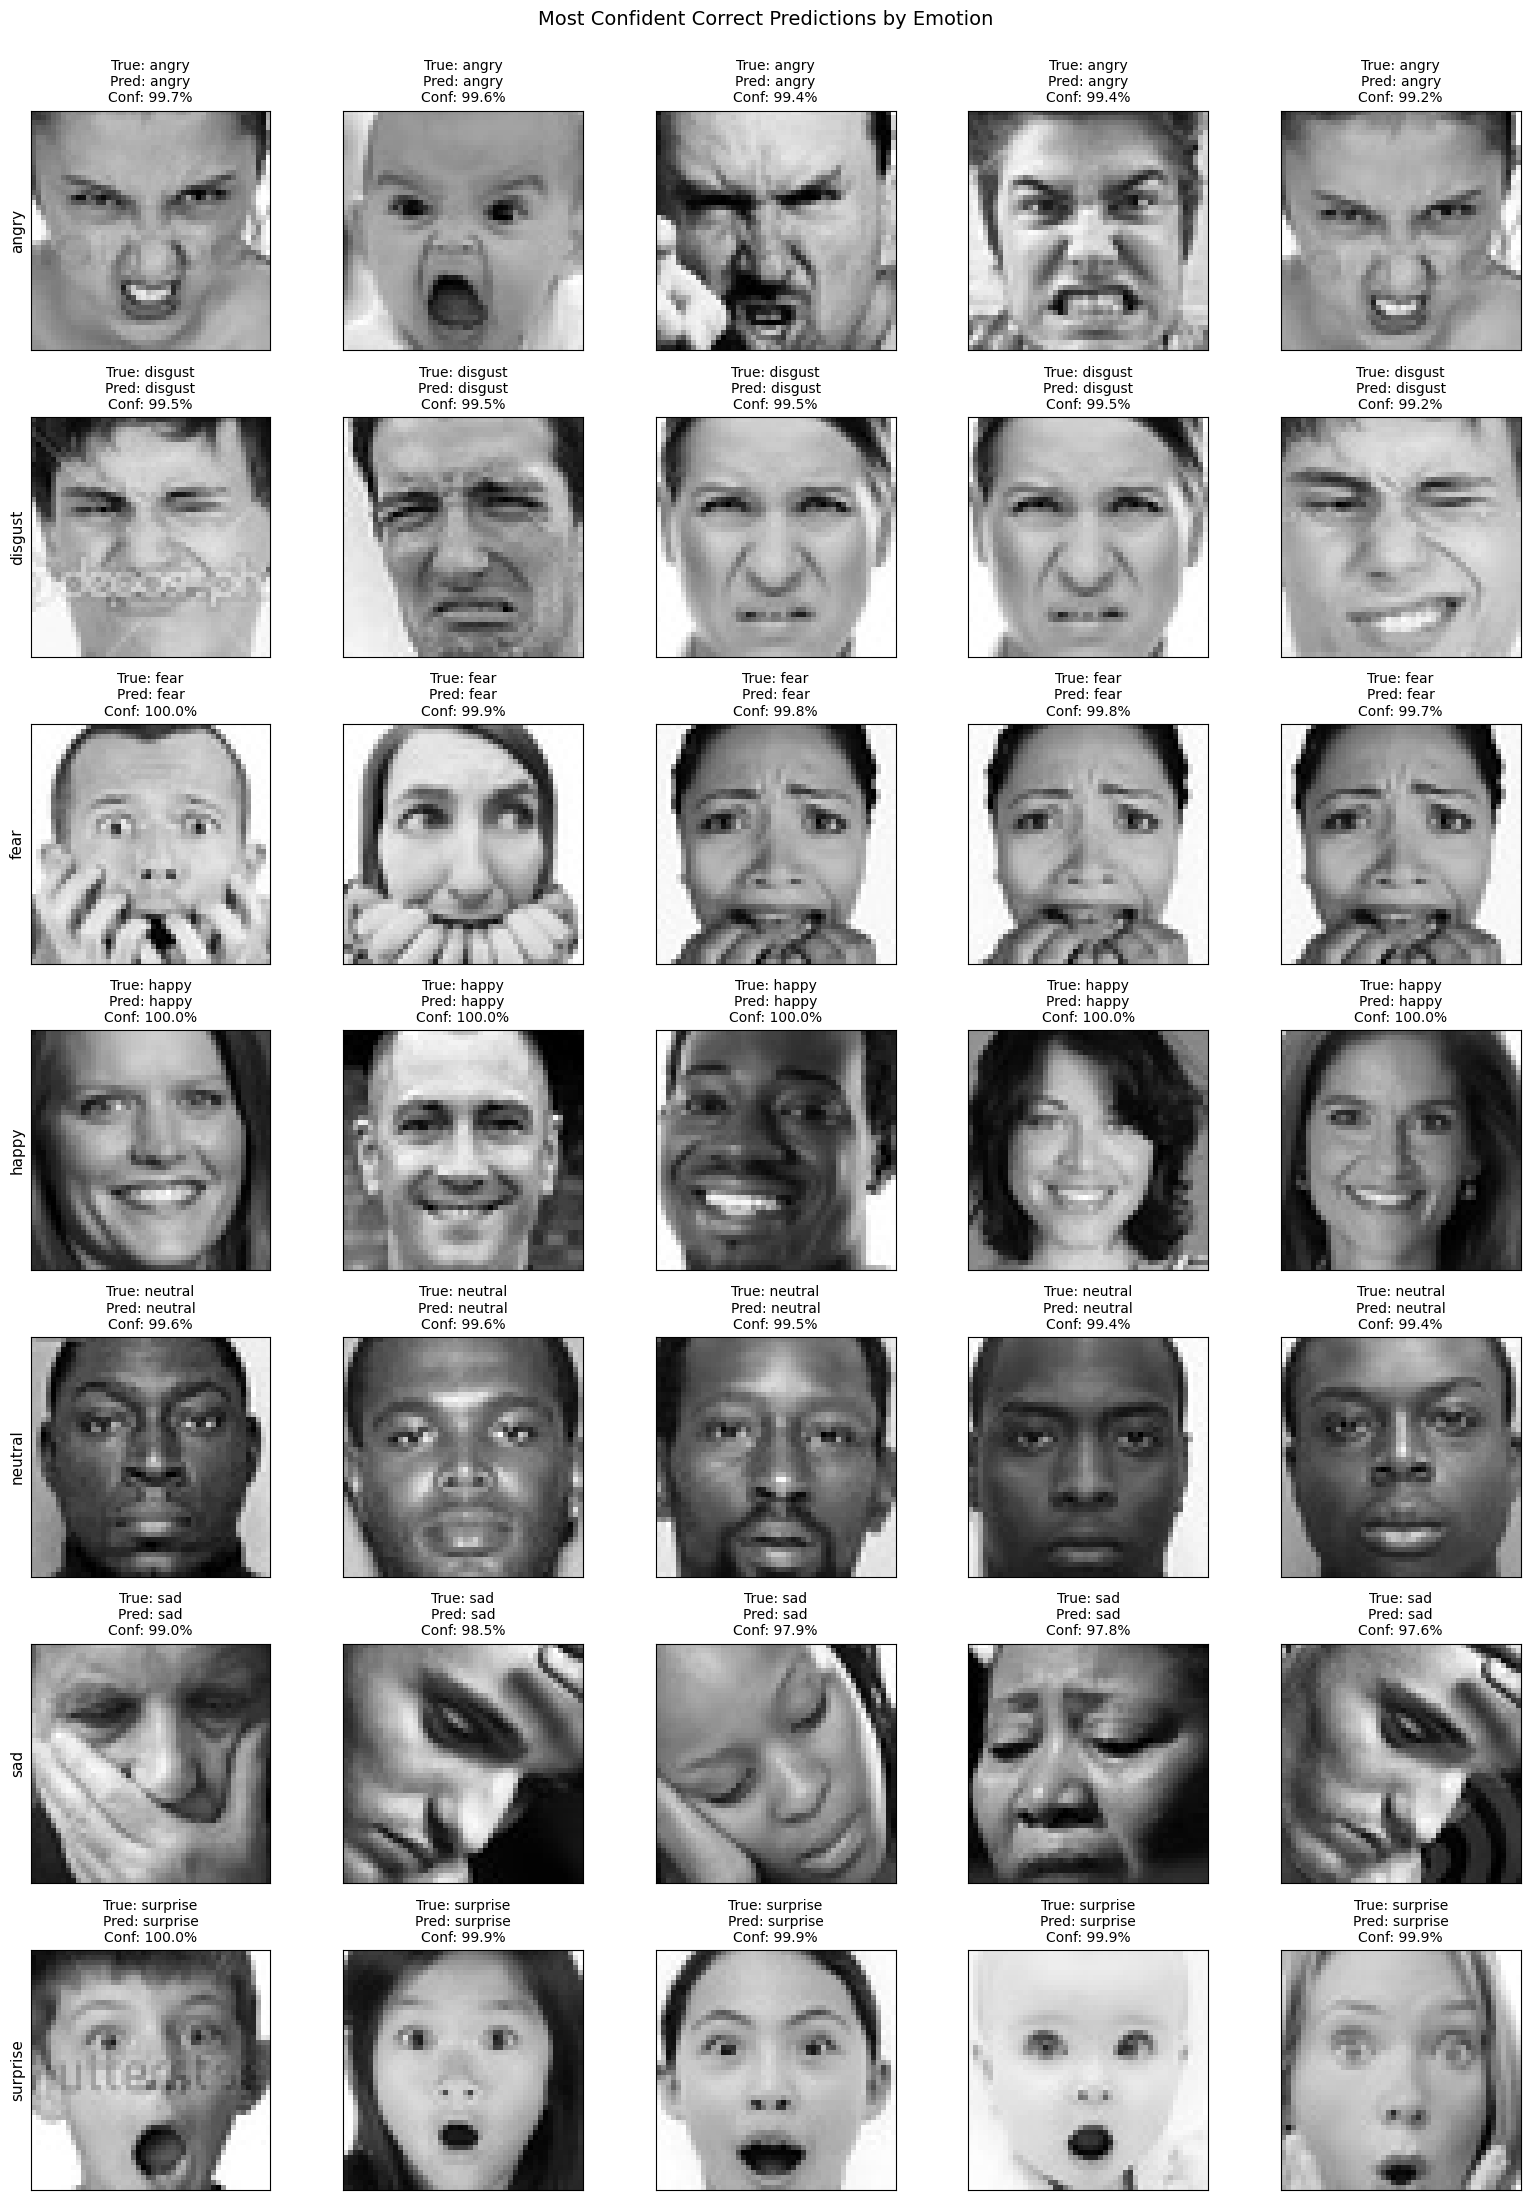

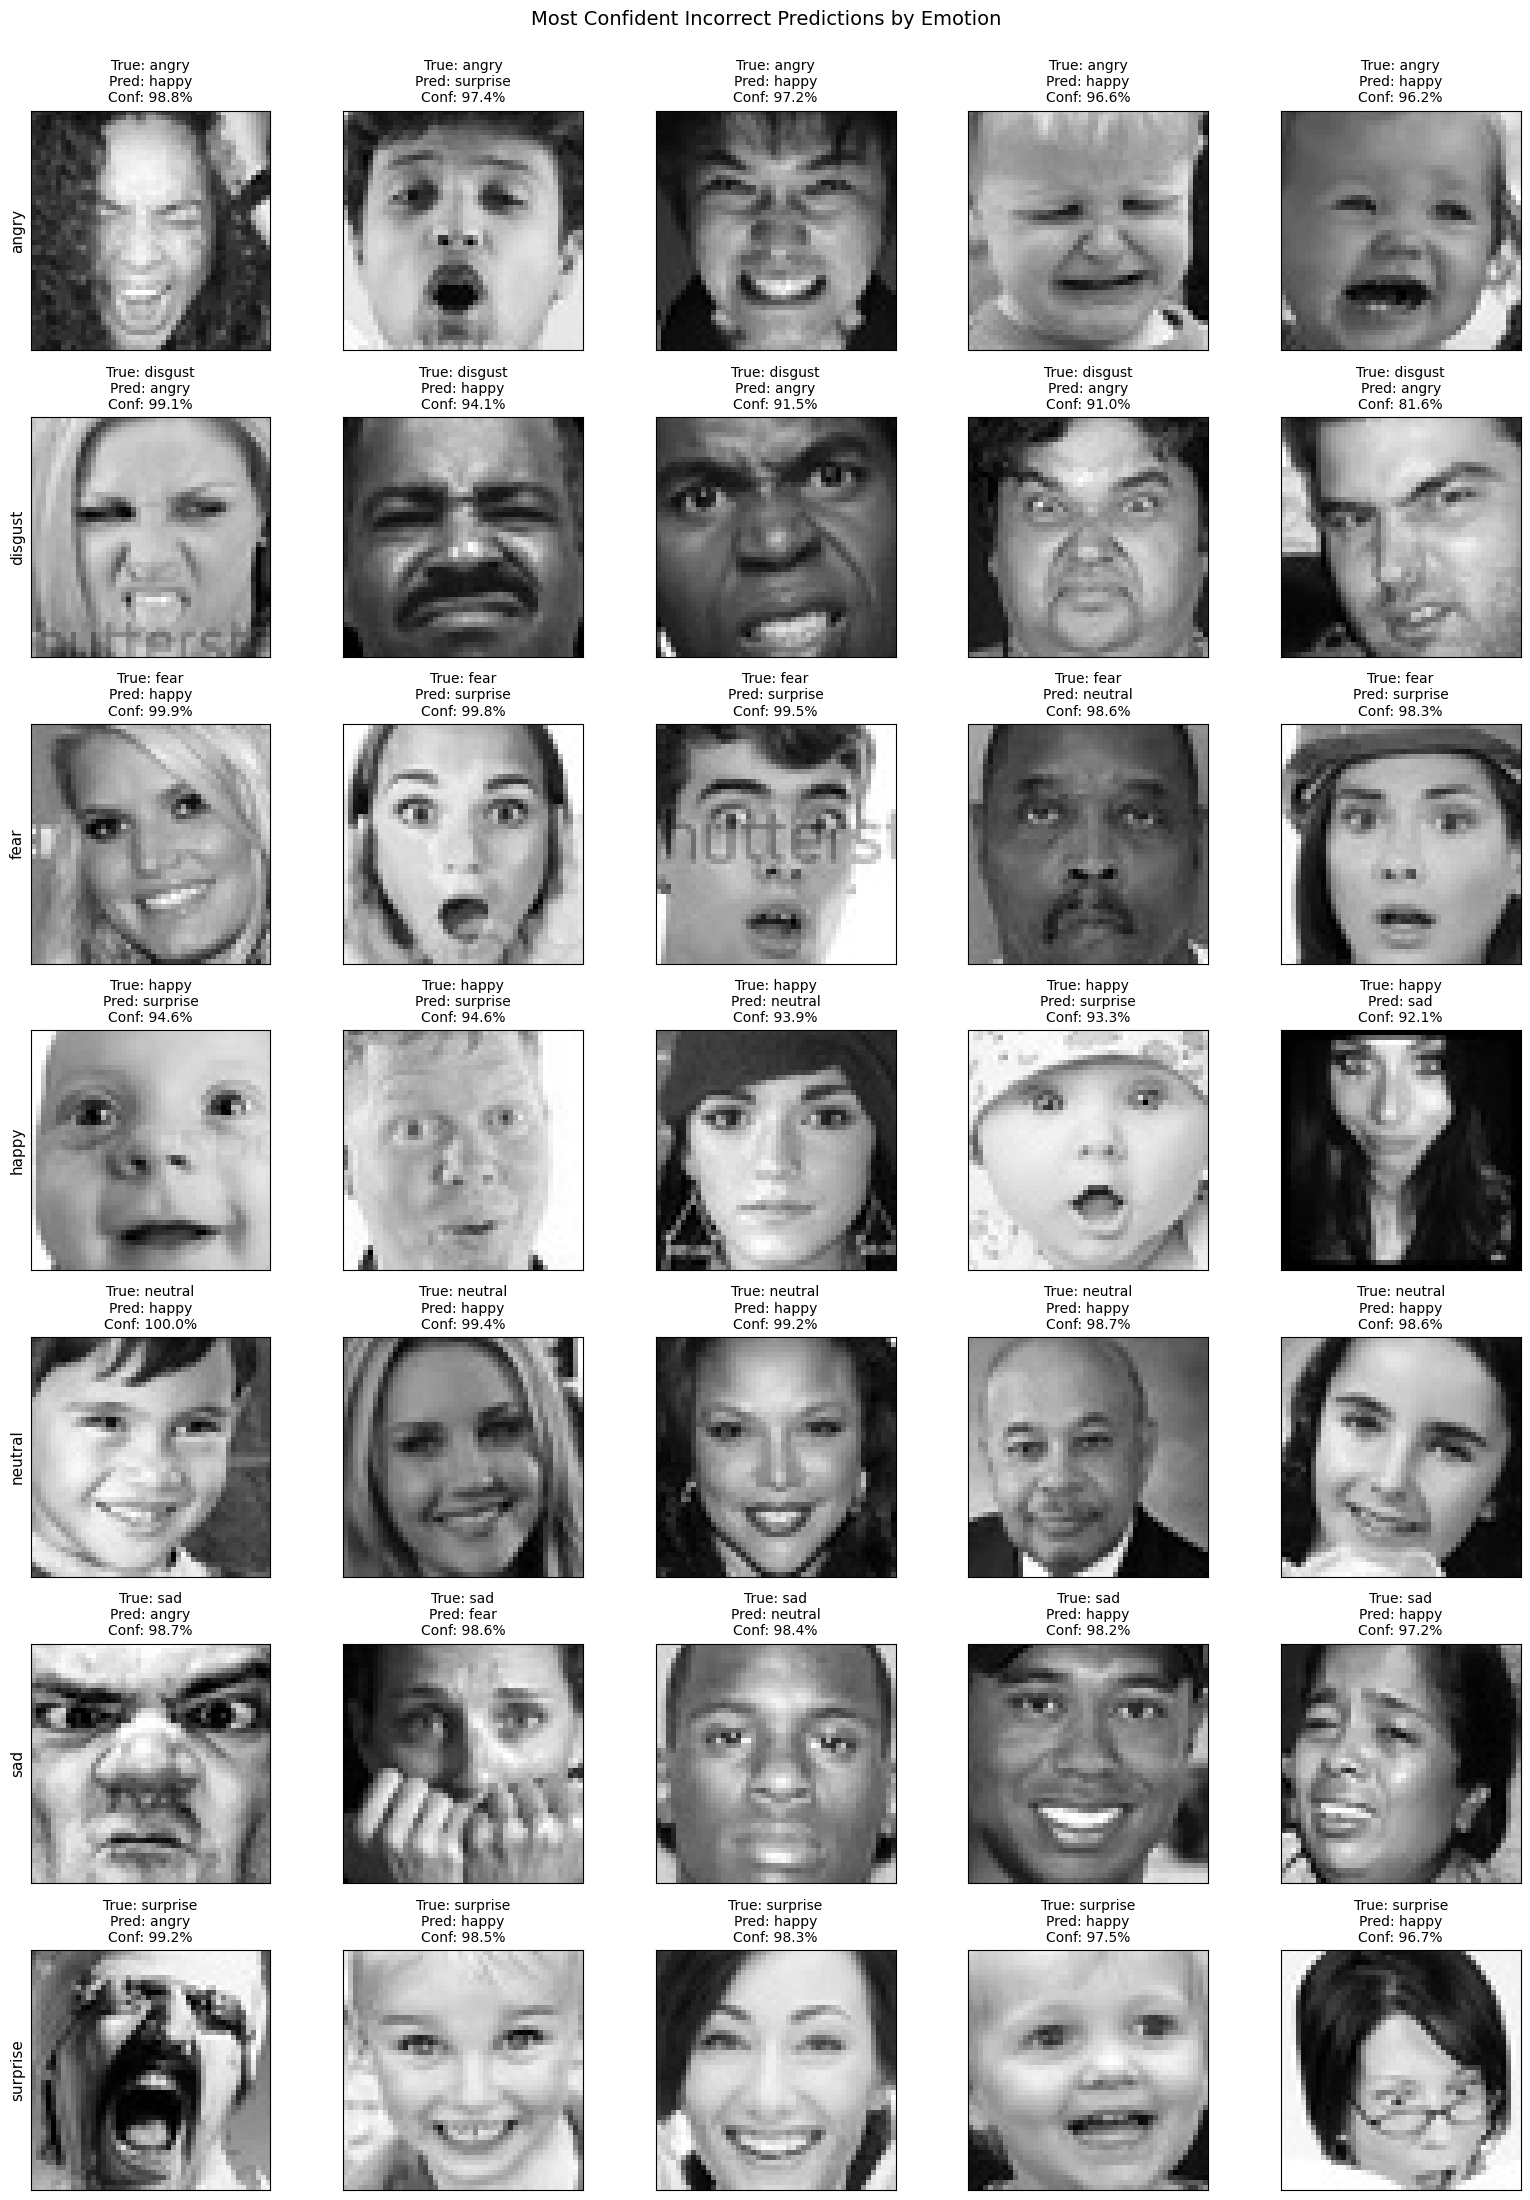

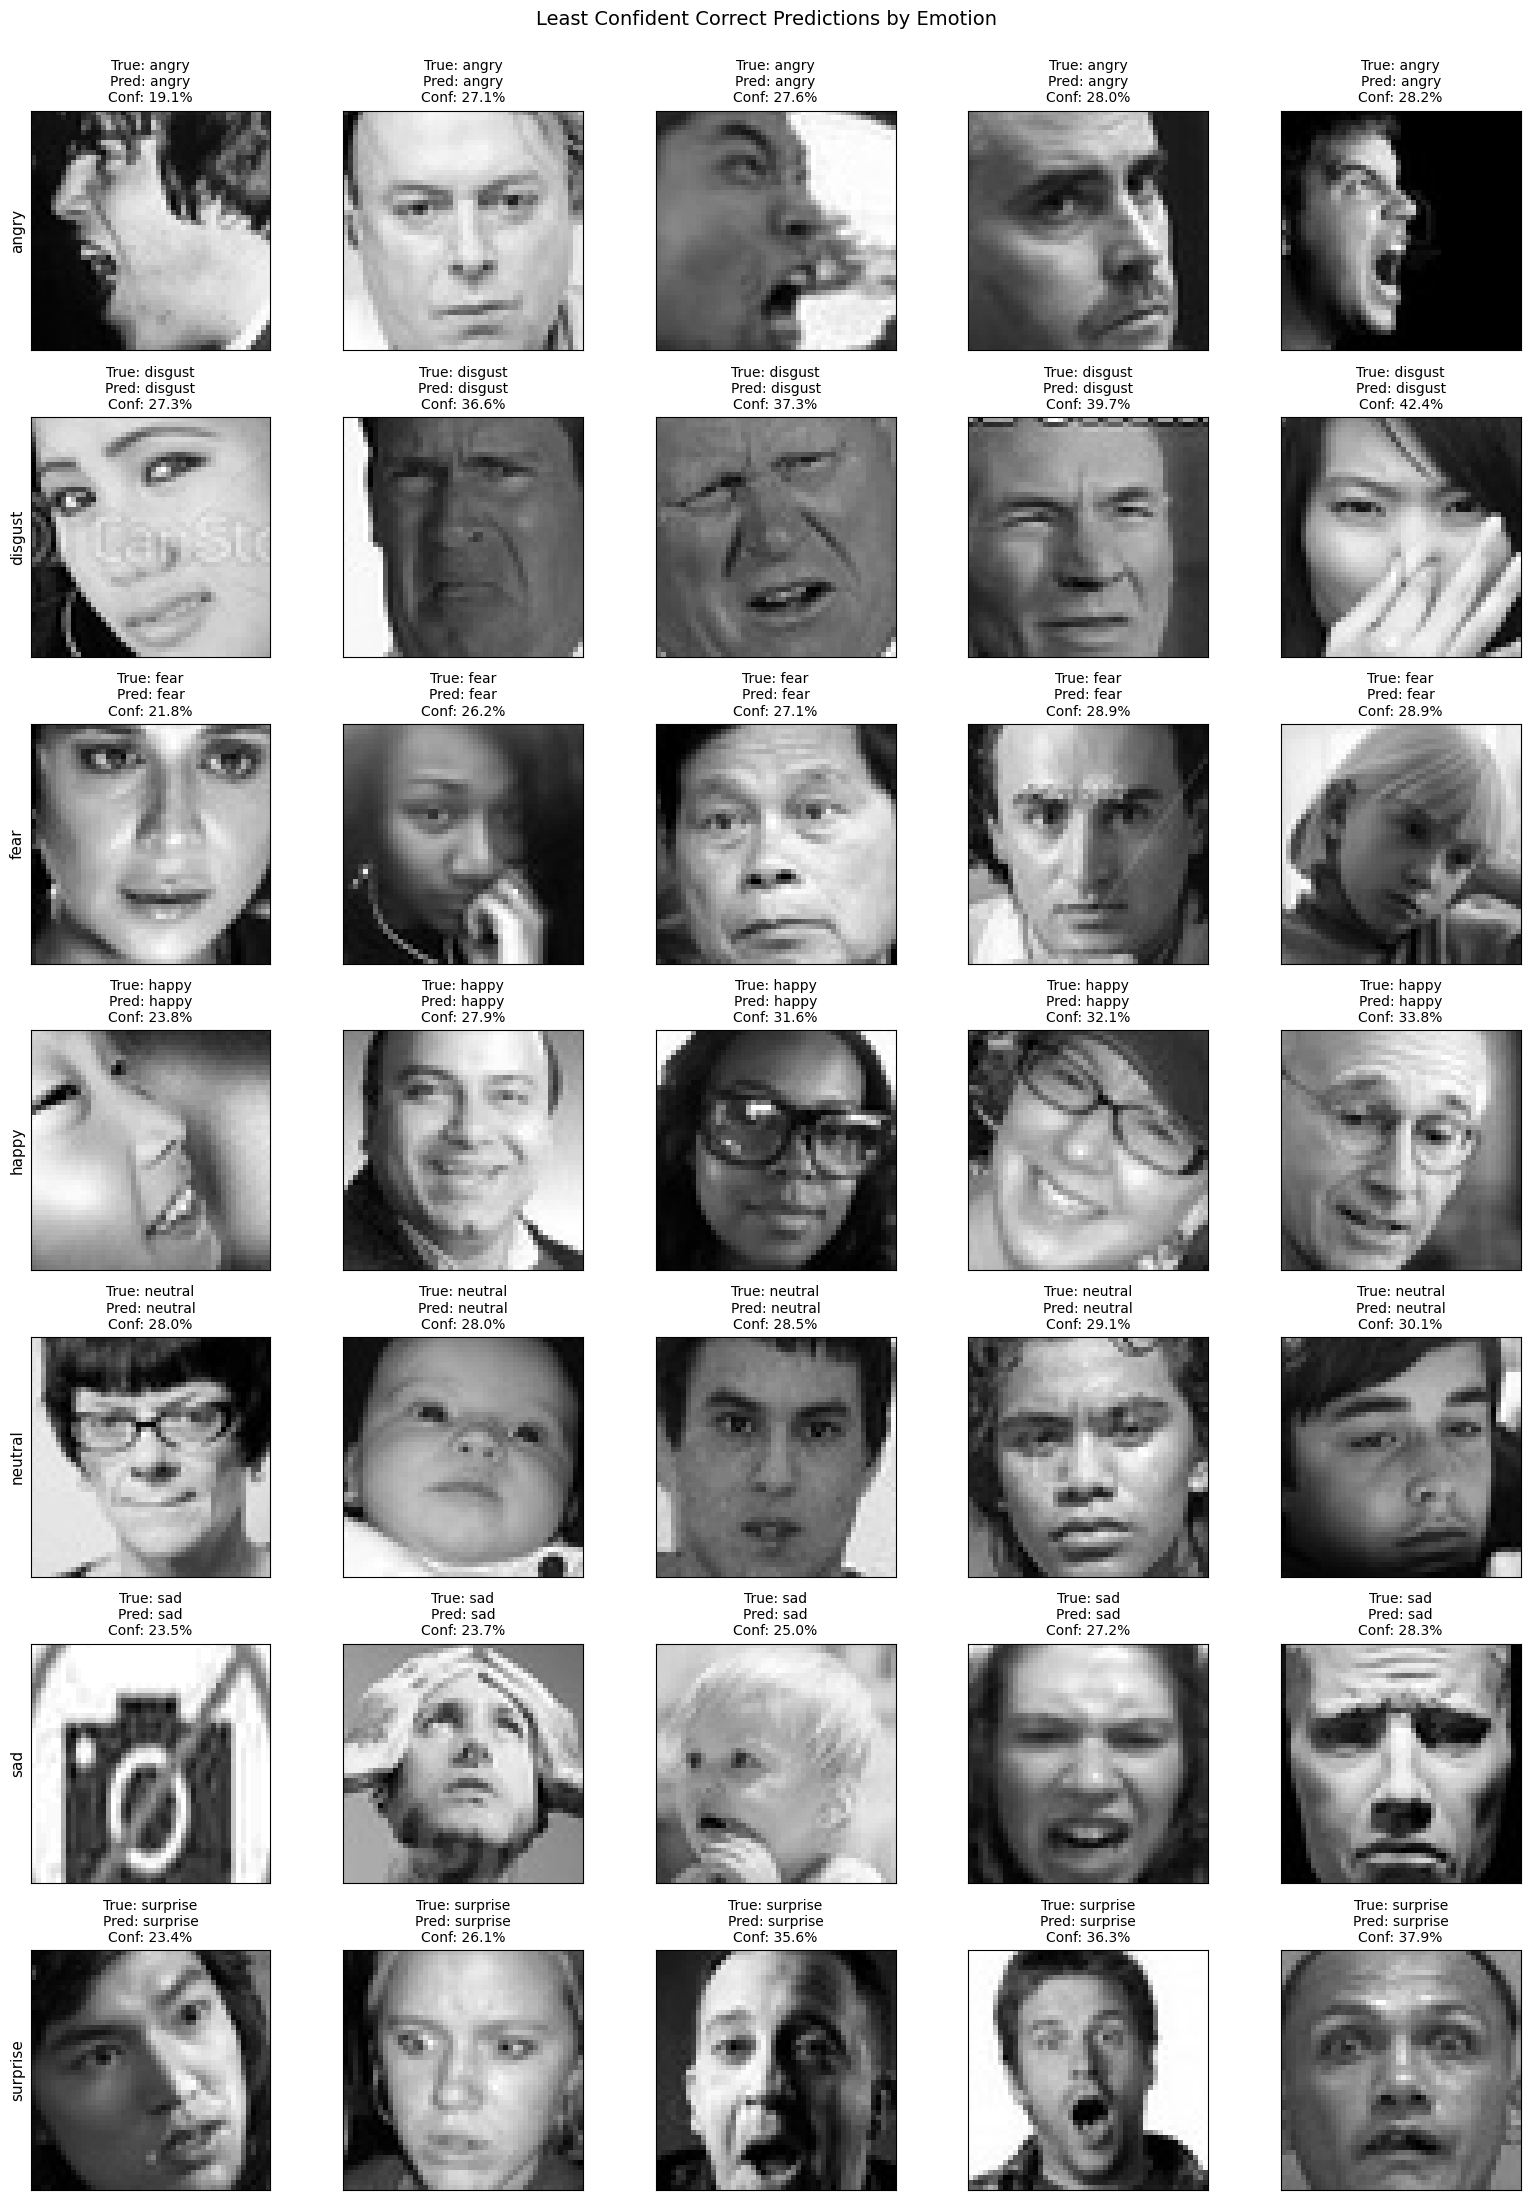

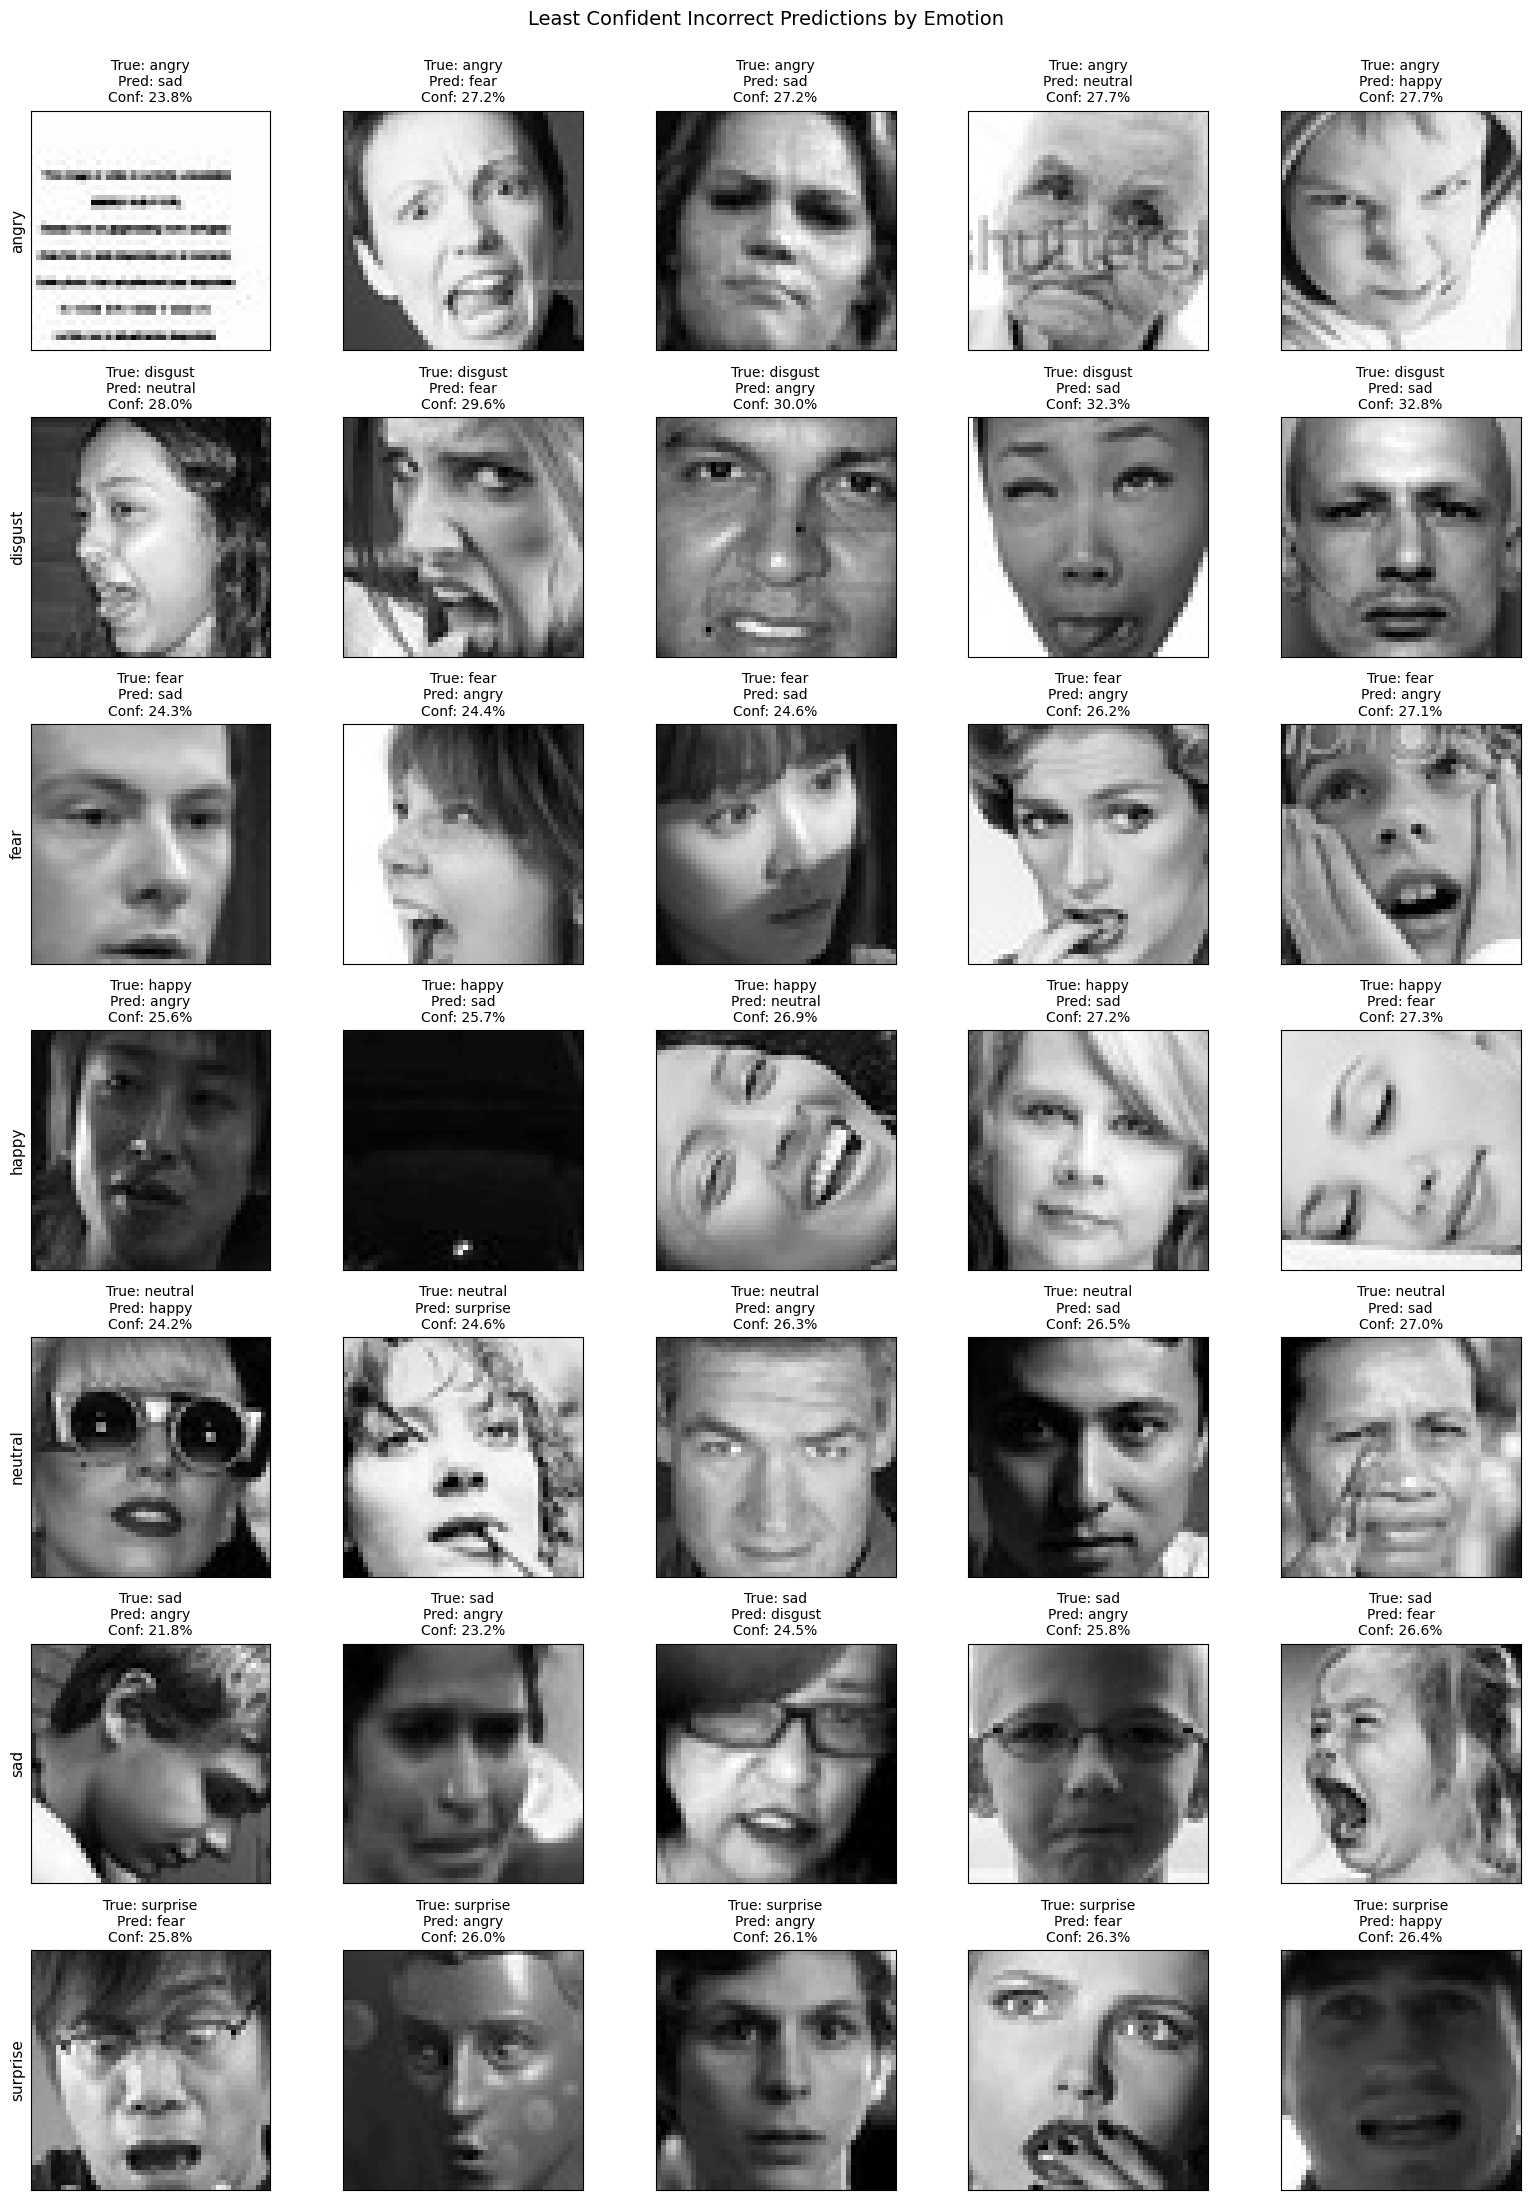

In [23]:
from vanillaCNN import (
    bottom_samples_by_true_class,
    collect_prediction_records,
    plot_ranked_samples_by_class,
    top_samples_by_true_class,
)

sort_by = "predicted_confidence"
top_k = 5

records = collect_prediction_records(
    model=loaded_model,  # or your trained model like model_best
    dataset=test_dataset,  # use the dataset, not the loader
    device=device,
    batch_size=32,
)

# Top-k most confident correct predictions for each true emotion
top_correct = top_samples_by_true_class(
    records,
    correct=True,
    top_k=top_k,
    sort_by=sort_by,
)

# Top-k most confident wrong predictions for each true emotion
top_incorrect = top_samples_by_true_class(
    records,
    correct=False,
    top_k=top_k,
    sort_by=sort_by,
)

# Top-k least confident correct predictions for each true emotion
bottom_correct = bottom_samples_by_true_class(
    records,
    correct=True,
    top_k=top_k,
    sort_by=sort_by,
)

# Top-k least confident wrong predictions for each true emotion
bottom_incorrect = bottom_samples_by_true_class(
    records,
    correct=False,
    top_k=top_k,
    sort_by=sort_by,
)

plot_ranked_samples_by_class(
    test_dataset,
    top_correct,
    title="Most Confident Correct Predictions by Emotion",
)

plot_ranked_samples_by_class(
    test_dataset,
    top_incorrect,
    title="Most Confident Incorrect Predictions by Emotion",
)

plot_ranked_samples_by_class(
    test_dataset,
    bottom_correct,
    title="Least Confident Correct Predictions by Emotion",
)

plot_ranked_samples_by_class(
    test_dataset,
    bottom_incorrect,
    title="Least Confident Incorrect Predictions by Emotion",
)


In [21]:
from checkpoint_utils import checkpoint_exists, save_model_checkpoint, load_model_checkpoint

checkpoint_path = "checkpoints/vanilla_cnn_best.pt"
model_kwargs = {
    "num_classes": len(train_dataset.classes),
    "dropout_rate": 0.25,
    "fc_dropout": 0.5,
}

model_vanilla = VanillaCNN(**model_kwargs).to(device)

if checkpoint_exists(checkpoint_path):
    metadata = load_model_checkpoint(model_vanilla, checkpoint_path, device=device)
    history_vanilla = metadata.get("history")
    print(f"Loaded saved model from {checkpoint_path}")
else:
    history_vanilla = train_model(
        model_vanilla,
        train_loader,
        test_loader,
        num_epochs=30,
        lr=0.001,
        patience=10,
        use_amp=amp_enabled,
    )
    save_model_checkpoint(
        model_vanilla,
        checkpoint_path,
        model_kwargs=model_kwargs,
        class_names=train_dataset.classes,
        history=history_vanilla,
    )
    print(f"Saved trained model to {checkpoint_path}")


Loaded saved model from checkpoints/vanilla_cnn_best.pt


In [22]:
torch.save(model_vanilla.state_dict(), 'vanilla_cnn.pth')